<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Simple_Multi_CPW_Hanger_Mode_Resonators_with_GDSTK_PHIDL_NetworkX_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install phidl gdstk networkx matplotlib numpy

Using Python 3.13.15 environment at: /usr
Resolved 15 packages in 3.75s
Prepared 3 packages in 10.35s
Installed 3 packages in 6ms
 + gdspy==1.6.13
 + gdstk==1.0.1
 + phidl==1.7.2


Pylint preflight: SKIP (Pylint is not installed).


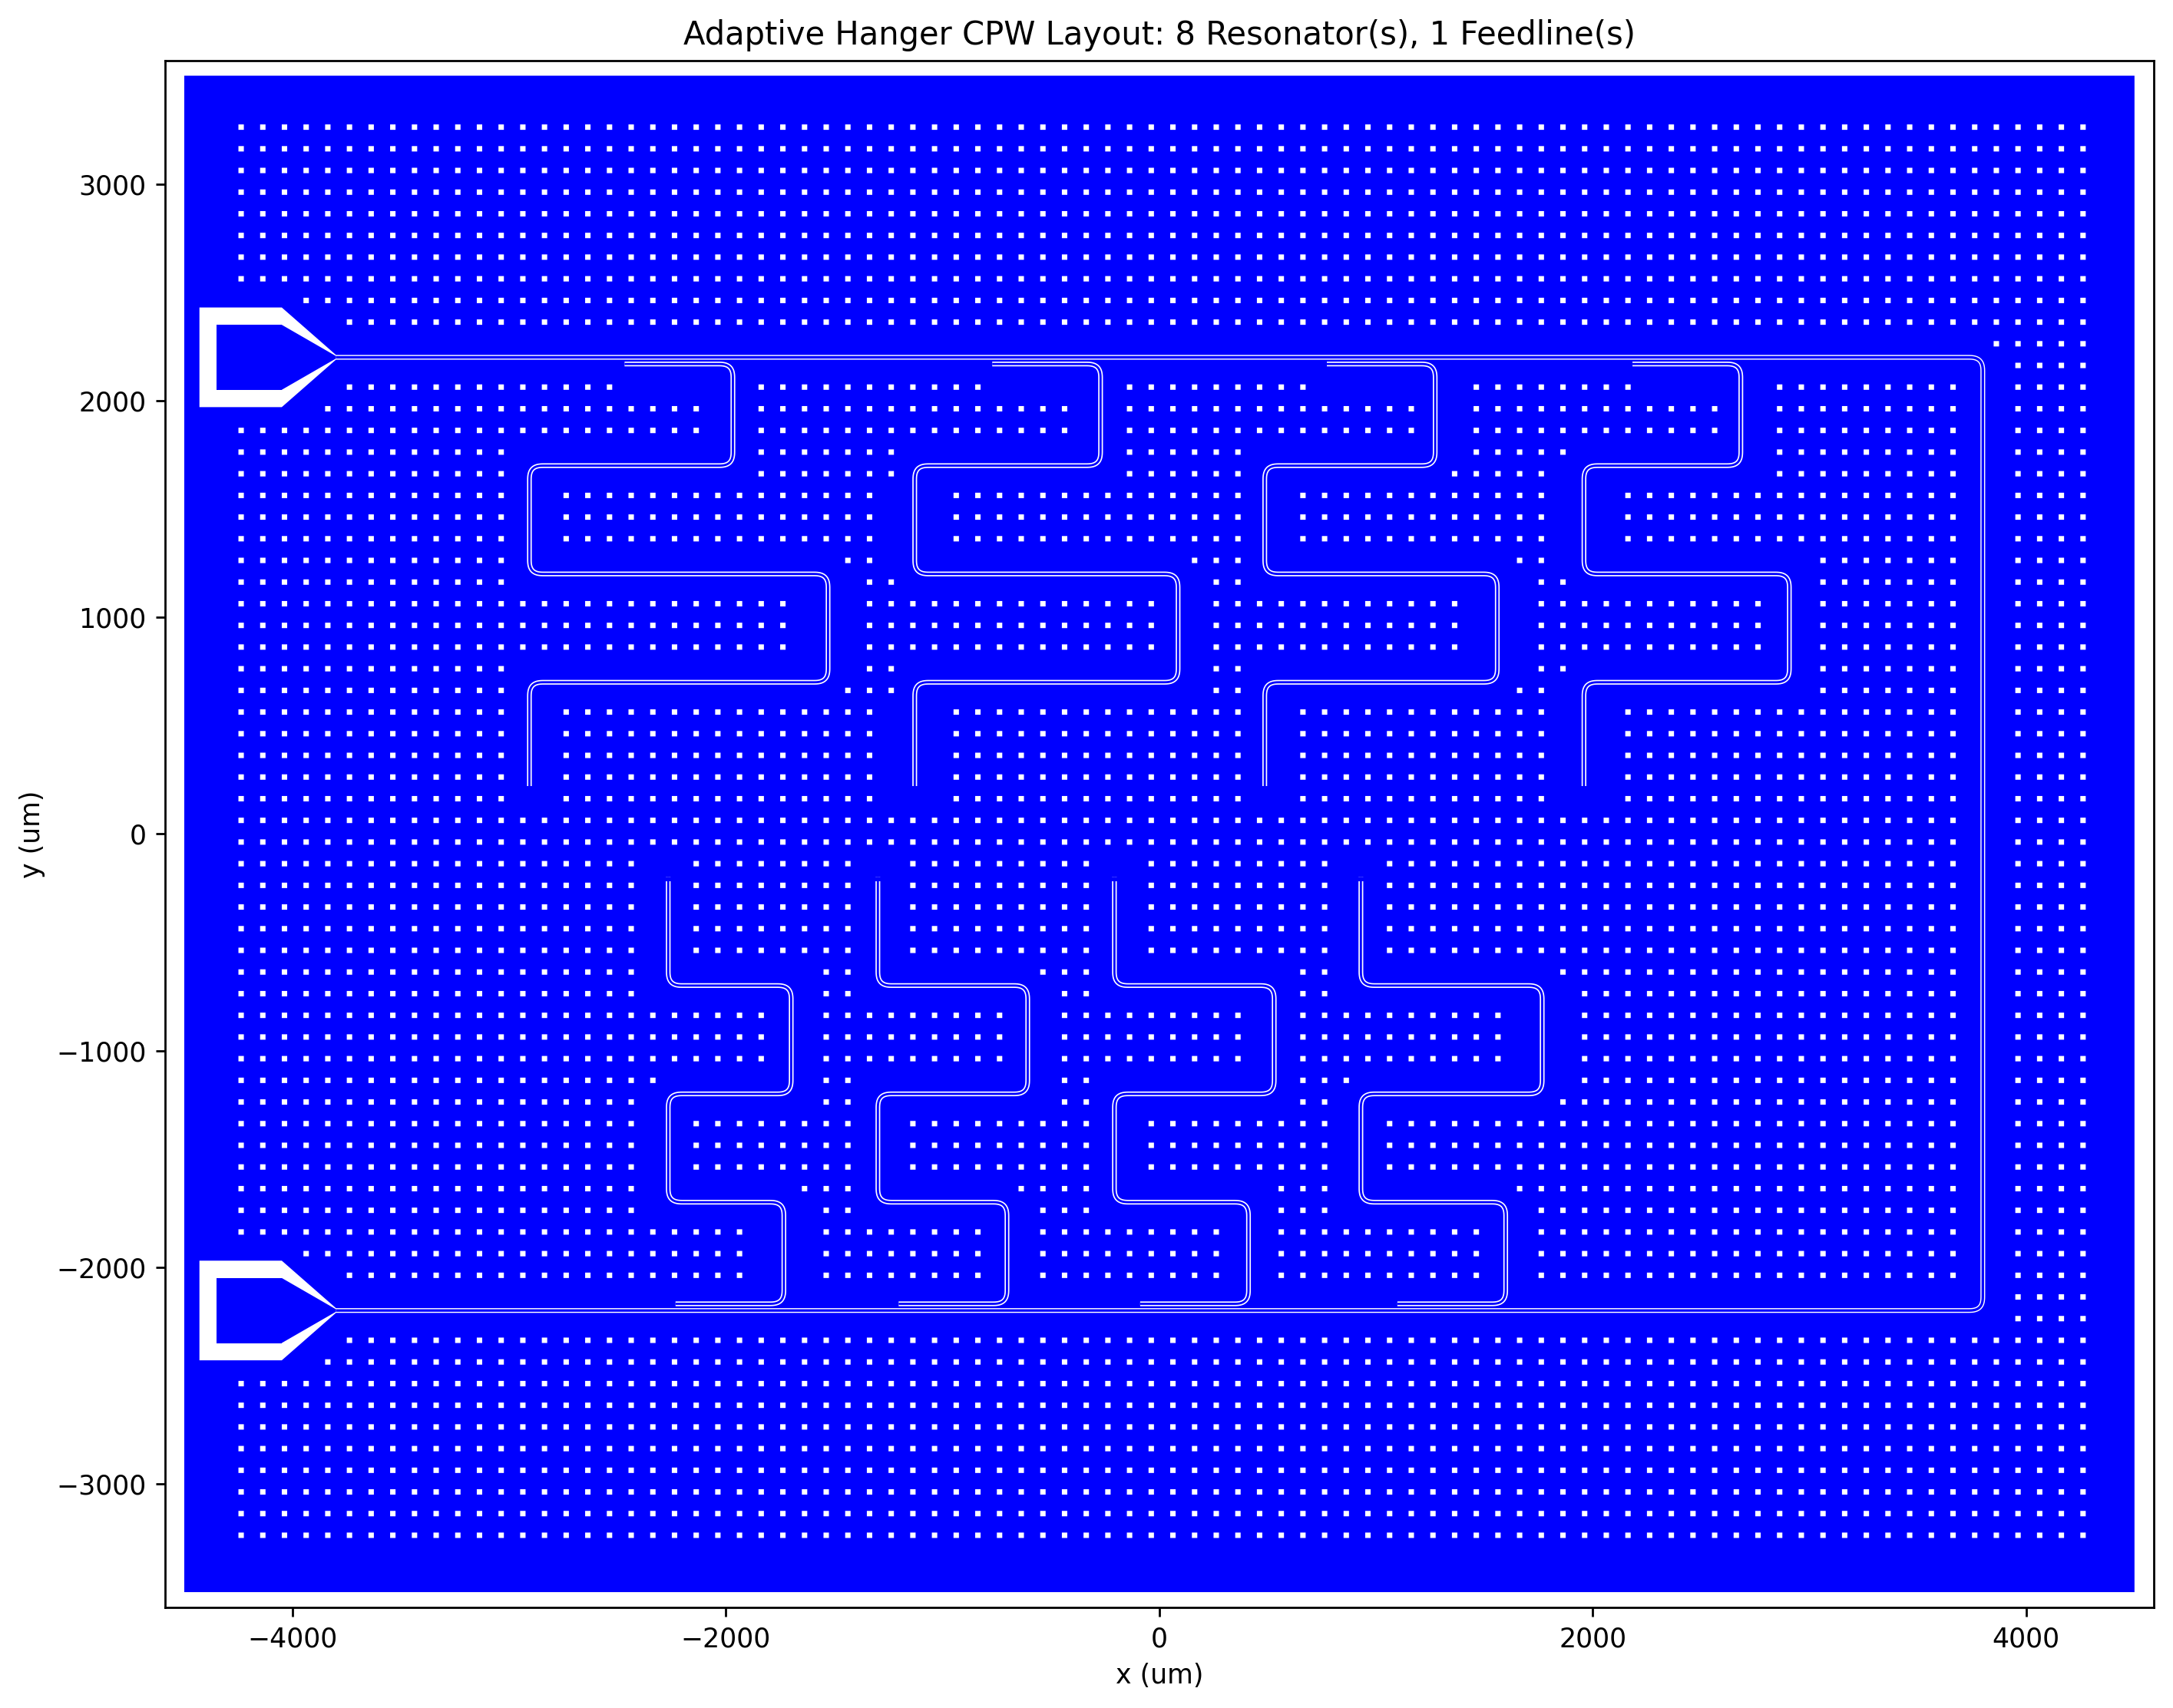

Package versions:
  gdstk: 1.0.1
  phidl: 1.7.2
  networkx: 3.6.1
Effective permittivity: 6.225000
Requested resonators: 8
Available listed frequencies: 12
Generated resonators: 8
Requested feedlines: 1
Stagger resonators: True
Adaptive resonator avoidance: True, requested=400.000 um, effective=400.000 um
Place resonators inside meander: True
Feedline meander pass pitch: 4400.000 um
Feedline 0: passes=2, length=19555.187 um, resonators=8, end_side=left
  pass y coordinates: 2200.000 um, -2200.000 um
Resonator 0: target=5.000000 GHz, realized=4.999996998 GHz, length=6007.880561 um, half_width=689.115 um, levels=3, feedline=0, pass=0, side=below
Resonator 1: target=5.363600 GHz, realized=5.363600643 GHz, length=5600.600561 um, half_width=607.659 um, levels=3, feedline=0, pass=0, side=below
Resonator 2: target=5.727300 GHz, realized=5.727296076 GHz, length=5244.950561 um, half_width=536.529 um, levels=3, feedline=0, pass=0, side=below
Resonator 3: target=6.090900 GHz, realized=6.090901346

In [8]:
"""Generate adaptive multi-feedline hanger-mode CPW layouts in Google Colab.

The layout uses NetworkX for routing topology, PHIDL for Euler-smoothed
centerline construction, and GDSTK for polygon generation, boolean ground-plane
processing, in-memory flattening, plotting data extraction, and OASIS export.
The resonator bank is frequency-list driven. Feedline routing and resonator
placement adapt to the requested resonator and feedline counts, including
serpentine feedline passes, inward-facing hanger placement, and configurable
resonator-to-resonator avoidance when the straight coupling span is full.
"""

import importlib.util
import inspect
import math
import os
import pdb
import re
import subprocess
import sys
import zlib
from dataclasses import dataclass, field
from importlib import metadata
from pathlib import Path as FilePath
from typing import Any, Callable, Final, Iterable, Sequence

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import phidl.geometry as pg
import phidl.path as pp
from phidl import Device


# -----------------------------------------------------------------------------
# Control knobs - package/API contract
# -----------------------------------------------------------------------------

MIN_GDSTK_VERSION: Final[str] = "1.0.1"
MIN_PHIDL_VERSION: Final[str] = "1.7.2"
MIN_NETWORKX_VERSION: Final[str] = "3.6.1"
ENABLE_PDB_ON_UNEXPECTED_EXCEPTION: Final[bool] = False
ENABLE_PYLINT_ERROR_PREFLIGHT: Final[bool] = True
PYLINT_MISSING_IS_FATAL: Final[bool] = False


# -----------------------------------------------------------------------------
# Control knobs - output and units
# -----------------------------------------------------------------------------

OUTPUT_OAS_PATH: Final[str] = "/content/adaptive_multi_hanger_cpw.oas"
TOP_CELL_NAME: Final[str] = "ADAPTIVE_MULTI_HANGER_CPW_TOP"
LIBRARY_NAME: Final[str] = "ADAPTIVE_MULTI_HANGER_CPW"
LIBRARY_UNIT_M: Final[float] = 1e-6
LIBRARY_PRECISION_M: Final[float] = 1e-9
OAS_COMPRESSION_LEVEL: Final[int] = 6
OAS_VALIDATION: Final[str] = "crc32"


# -----------------------------------------------------------------------------
# Control knobs - coordinate grid and geometry precision
# -----------------------------------------------------------------------------

ENABLE_GRID_SNAPPING: Final[bool] = True
FABRICATION_GRID_UM: Final[float] = 0.001
BOOLEAN_PRECISION_UM: Final[float] = FABRICATION_GRID_UM
PATH_TOLERANCE_UM: Final[float] = 0.005
EULER_POINTS_PER_360: Final[int] = 720


# -----------------------------------------------------------------------------
# Control knobs - chip and layers
# -----------------------------------------------------------------------------

CHIP_WIDTH_UM: Final[float] = 9000.0
CHIP_HEIGHT_UM: Final[float] = 7000.0
CHIP_EDGE_DRC_MARGIN_UM: Final[float] = 50.0
METAL_LAYER: Final[int] = 1
METAL_DATATYPE: Final[int] = 0


# -----------------------------------------------------------------------------
# Control knobs - feedline CPW and launchers
# -----------------------------------------------------------------------------

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_GAP_UM: Final[float] = 5.1
LAUNCHER_PAD_LENGTH_UM: Final[float] = 300.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 300.0
LAUNCHER_PAD_GAP_UM: Final[float] = 80.0
LAUNCHER_TAPER_LENGTH_UM: Final[float] = 250.0
LAUNCHER_EDGE_INSET_UM: Final[float] = 150.0


# -----------------------------------------------------------------------------
# Control knobs - adaptive resonator bank and feedline routing
# -----------------------------------------------------------------------------

# Requested resonator count. Set this to 1 to generate only the first listed
# target frequency.
DESIRED_RESONATOR_COUNT: Final[int] = 8

# Frequencies are consumed in list order. If DESIRED_RESONATOR_COUNT is smaller
# than this tuple, only the first requested entries are generated. If it is
# larger, generation stops at the final available frequency instead of inventing
# additional targets. With a count of 1, only the first listed target is used.
TARGET_RESONATOR_FREQUENCIES_HZ: Final[tuple[float, ...]] = (
    5.0000e9,
    5.3636e9,
    5.7273e9,
    6.0909e9,
    6.4545e9,
    6.8182e9,
    7.0000e9,
    7.5455e9,
    7.9091e9,
    8.2727e9,
    8.6364e9,
    9.0000e9,
)

# Requested independent CPW feedline count. Resonators are assigned round-robin
# so the frequency ordering stays deterministic as this count changes.
DESIRED_FEEDLINE_COUNT: Final[int] = 1

# Staggering shifts alternate feedline passes laterally by as much as the stated
# amount whenever unused horizontal packing slack exists. Set False for aligned
# resonator columns across adjacent feedline passes.
STAGGER_RESONATORS: Final[bool] = True
RESONATOR_STAGGER_MAX_OFFSET_UM: Final[float] = 250.0

# Adaptive collision-aware resonator packing and pairwise spacing.
ENABLE_ADAPTIVE_RESONATOR_AVOIDANCE: Final[bool] = True

# Default CPW resonator-to-resonator metal-edge avoidance: 100 micrometers.
# Increase this value to reserve more spacing between every resonator pair. The
# hard MIN_TRACE_TO_TRACE_SPACING_UM rule acts as the lower DRC floor.
RESONATOR_TO_RESONATOR_AVOIDANCE_UM: Final[float] = 400.0

# Straight feedline passes acquire resonators until their available coupling span
# is full. If enabled, another Euler-smoothed pass is added automatically.
AUTO_MEANDER_FEEDLINE_IF_NEEDED: Final[bool] = True
FEEDLINE_TURN_KEEPOUT_UM: Final[float] = 250.0

# If a feedline acquires multiple serpentine passes, orient every hanger toward
# the vertical interior enclosed by that feedline. A single straight pass keeps
# the original below-feedline orientation.
PLACE_RESONATORS_INSIDE_MEANDER: Final[bool] = True

# Leave this as None to derive a pass pitch that can contain inward-facing
# resonators from adjacent passes plus the resonator-to-resonator avoidance.
# A positive value forces a custom pitch and is still checked by the DRC.
FEEDLINE_MEANDER_PASS_PITCH_UM: Final[float | None] = None
FEEDLINE_GROUP_VERTICAL_GAP_UM: Final[float] = 250.0


# -----------------------------------------------------------------------------
# Control knobs - resonator physics and coupling
# -----------------------------------------------------------------------------

SUBSTRATE_RELATIVE_PERMITTIVITY: Final[float] = 11.45
EFFECTIVE_PERMITTIVITY_OVERRIDE: Final[float | None] = None
RESONATOR_TRACE_WIDTH_UM: Final[float] = 10.0
RESONATOR_GAP_UM: Final[float] = 6.0

# Edge-to-edge distance between the feedline trace and its parallel hanger
# coupler trace. Default: 20 micrometers.
HANGER_COUPLER_EDGE_GAP_UM: Final[float] = 20.0
RESONATOR_COUPLER_LENGTH_UM: Final[float] = 500.0
RESONATOR_BEND_RADIUS_UM: Final[float] = 70.0
RESONATOR_EULER_FRACTION: Final[float] = 1.0

# Exact local centerline distance from each assigned feedline pass to the
# furthest resonator tip. Default: 2000 micrometers.
FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM: Final[float] = 2000.0

AUTO_ADAPT_RESONATOR_TO_TIP_DISTANCE: Final[bool] = True
PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 3
MIN_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 1
MAX_RESONATOR_MEANDER_LEVEL_COUNT: Final[int] = 7

# Set a positive value to force one common half width for every resonator. Leave
# None to solve each resonator independently from its listed target frequency.
RESONATOR_MEANDER_HALF_WIDTH_UM: Final[float | None] = None
RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM: Final[tuple[float, float]] = (80.0, 1600.0)
RESONATOR_LENGTH_SOLVER_TOLERANCE_UM: Final[float] = 0.001
RESONATOR_LENGTH_DRC_TOLERANCE_UM: Final[float] = 0.05
RESONATOR_FREQUENCY_DRC_TOLERANCE_MHZ: Final[float] = 0.10

SHORT_GROUND_OVERLAP_UM: Final[float] = 20.0
SHORT_BAR_DEPTH_UM: Final[float] = 20.0


# -----------------------------------------------------------------------------
# Control knobs - manual DRC
# -----------------------------------------------------------------------------

MIN_TRACE_WIDTH_UM: Final[float] = 5.0
MIN_GAP_SPACING_UM: Final[float] = 4.0
MIN_TRACE_TO_TRACE_SPACING_UM: Final[float] = 8.0
MIN_BEND_RADIUS_UM: Final[float] = 50.0
GRID_DRC_ATOL_UM: Final[float] = 5e-7


# -----------------------------------------------------------------------------
# Control knobs - ground-plane cheesing and keepouts
# -----------------------------------------------------------------------------

ENABLE_CHEESING: Final[bool] = True
ENABLE_CHEESING_AVOIDANCE: Final[bool] = True
CHEESE_HOLE_WIDTH_UM: Final[float] = 25.0
CHEESE_HOLE_HEIGHT_UM: Final[float] = 25.0
CHEESE_PITCH_X_UM: Final[float] = 100.0
CHEESE_PITCH_Y_UM: Final[float] = 100.0
CHEESE_COMPONENT_KEEPOUT_UM: Final[float] = 80.0
CHEESE_CHIP_EDGE_KEEPOUT_UM: Final[float] = 250.0
CHEESE_GRID_OFFSET_X_UM: Final[float] = 0.0
CHEESE_GRID_OFFSET_Y_UM: Final[float] = 0.0


# -----------------------------------------------------------------------------
# Control knobs - optional junction import
# -----------------------------------------------------------------------------

INCLUDE_JUNCTION_CELL: Final[bool] = False
JUNCTION_GDS_PATH: Final[str | None] = None
JUNCTION_CELL_NAME: Final[str | None] = None
JUNCTION_ORIGIN_UM: Final[tuple[float, float]] = (0.0, -1000.0)


# -----------------------------------------------------------------------------
# Control knobs - in-memory plot
# -----------------------------------------------------------------------------

PLOT_DPI: Final[int] = 250
PLOT_FIGSIZE_IN: Final[tuple[float, float]] = (12.0, 9.0)
PLOT_METAL_COLOR: Final[str] = "#0000FF"
PLOT_LINEWIDTH: Final[float] = 0.0
PLOT_SHOW_AXES: Final[bool] = True


SPEED_OF_LIGHT_M_PER_S: Final[float] = 299_792_458.0


class LayoutContractError(RuntimeError):
    """Raised when a runtime API or package contract is incompatible."""


class DrcViolation(RuntimeError):
    """Raised immediately when the manual layout DRC detects a violation."""


@dataclass(frozen=True)
class LauncherGeometry:
    """Signal and clearance polygons for one CPW launcher."""

    signal: tuple[gdstk.Polygon, ...]
    clearance: tuple[gdstk.Polygon, ...]
    feedline_connection: tuple[float, float]
    pad_center: tuple[float, float]
    side: str


@dataclass(frozen=True)
class ResonatorSolution:
    """Frequency-dependent resonator sizing before chip placement."""

    index: int
    target_frequency_hz: float
    target_length_um: float
    meander_half_width_um: float
    meander_level_count: int
    reservation_width_um: float


@dataclass(frozen=True)
class ResonatorPlacement:
    """Placement of one solved resonator on one feedline pass."""

    resonator_index: int
    feedline_index: int
    pass_index: int
    coupler_center_x_um: float
    feedline_y_um: float
    resonator_y_sign: int


@dataclass(frozen=True)
class FeedlinePlan:
    """Adaptive feedline pass assignment and row placement."""

    index: int
    pass_resonator_indices: tuple[tuple[int, ...], ...]
    pass_y_um: tuple[float, ...]
    placements: tuple[ResonatorPlacement, ...]
    start_side: str
    end_side: str


@dataclass(frozen=True)
class FeedlineGeometry:
    """One Euler-smoothed feedline and its diagnostics."""

    index: int
    signal: tuple[gdstk.Polygon, ...]
    clearance: tuple[gdstk.Polygon, ...]
    centerline: np.ndarray
    phidl_path: Any | None
    centerline_length_um: float
    pass_y_um: tuple[float, ...]
    start_side: str
    end_side: str


@dataclass(frozen=True)
class ResonatorGeometry:
    """Placed resonator geometry and centerline diagnostics."""

    index: int
    target_frequency_hz: float
    feedline_index: int
    pass_index: int
    feedline_y_um: float
    resonator_y_sign: int
    signal: tuple[gdstk.Polygon, ...]
    clearance: tuple[gdstk.Polygon, ...]
    short_bar: gdstk.Polygon
    centerline: np.ndarray
    phidl_path: Any
    centerline_length_um: float
    meander_half_width_um: float
    meander_level_count: int
    meander_y_levels_um: tuple[float, ...]
    open_end: tuple[float, float]
    tip: tuple[float, float]


@dataclass
class PhidlHierarchyEngine:
    """Manage PHIDL hierarchy, components, and component keepout geometry."""

    top_name: str
    top: Device = field(init=False)
    cells: dict[str, Device] = field(default_factory=dict, init=False)
    keepout_polygons: list[gdstk.Polygon] = field(default_factory=list, init=False)

    def __post_init__(self) -> None:
        self.top = Device(self.top_name)

    def add_component(
        self,
        name: str,
        polygons: Sequence[gdstk.Polygon],
        keepouts: Sequence[gdstk.Polygon] = (),
    ) -> Device:
        """Register one hierarchical PHIDL component from GDSTK polygons."""
        if name in self.cells:
            raise LayoutContractError(f"Duplicate PHIDL cell name: {name}")

        device = Device(name)
        for polygon in polygons:
            device.add_polygon(
                np.asarray(polygon.points, dtype=float),
                layer=(int(polygon.layer), int(polygon.datatype)),
            )
        self.top.add_ref(device)
        self.cells[name] = device
        self.keepout_polygons.extend(keepouts)
        return device

    def maybe_import_junction(self) -> Device | None:
        """Import a junction GDS cell only if the corresponding knob is enabled."""
        if not INCLUDE_JUNCTION_CELL:
            return None
        if not JUNCTION_GDS_PATH:
            raise LayoutContractError(
                "INCLUDE_JUNCTION_CELL is True, but JUNCTION_GDS_PATH is unset."
            )

        imported = safe_kw_call(
            pg.import_gds,
            JUNCTION_GDS_PATH,
            cellname=JUNCTION_CELL_NAME,
            flatten=False,
        )
        reference = self.top.add_ref(imported)
        reference.move(JUNCTION_ORIGIN_UM)
        self.cells[imported.name] = imported
        return imported


@dataclass
class GdstkHierarchyEngine:
    """Manage the final in-memory GDSTK library and cell hierarchy."""

    library_name: str
    top_name: str
    library: gdstk.Library = field(init=False)
    top: gdstk.Cell = field(init=False)
    cells: dict[str, gdstk.Cell] = field(default_factory=dict, init=False)

    def __post_init__(self) -> None:
        self.library = gdstk.Library(
            self.library_name,
            unit=LIBRARY_UNIT_M,
            precision=LIBRARY_PRECISION_M,
        )
        self.top = self.library.new_cell(self.top_name)

    def add_component(
        self,
        name: str,
        polygons: Sequence[gdstk.Polygon],
        origin: tuple[float, float] = (0.0, 0.0),
    ) -> gdstk.Cell:
        """Add one referenced GDSTK component cell to the library."""
        if name in self.cells:
            raise LayoutContractError(f"Duplicate GDSTK cell name: {name}")
        cell = self.library.new_cell(name)
        if polygons:
            cell.add(*polygons)
        self.top.add(gdstk.Reference(cell, origin=origin))
        self.cells[name] = cell
        return cell


def _version_tuple(version: str) -> tuple[int, int, int]:
    """Convert a package version into a three-integer comparison tuple."""
    numbers = [int(value) for value in re.findall(r"\d+", version)[:3]]
    numbers.extend([0] * (3 - len(numbers)))
    return tuple(numbers[:3])


def package_version(distribution_name: str) -> str:
    """Return the installed package version using distribution metadata."""
    try:
        return metadata.version(distribution_name)
    except metadata.PackageNotFoundError as exc:
        raise LayoutContractError(
            f"Required package '{distribution_name}' is not installed."
        ) from exc


def validate_package_versions() -> dict[str, str]:
    """Require the configured minimum package generations."""
    requirements = {
        "gdstk": MIN_GDSTK_VERSION,
        "phidl": MIN_PHIDL_VERSION,
        "networkx": MIN_NETWORKX_VERSION,
    }
    detected: dict[str, str] = {}
    for name, minimum in requirements.items():
        installed = package_version(name)
        detected[name] = installed
        if _version_tuple(installed) < _version_tuple(minimum):
            raise LayoutContractError(
                f"{name} {installed} is older than required {minimum}."
            )
    return detected


def require_attributes(owner: Any, names: Iterable[str], owner_name: str) -> None:
    """Fail early if an expected public API attribute is absent."""
    for name in names:
        if not hasattr(owner, name):
            raise LayoutContractError(
                f"Required API '{owner_name}.{name}' is unavailable."
            )


def validate_keyword_contract(
    function: Callable[..., Any],
    keywords: Iterable[str],
    function_name: str,
) -> None:
    """Check keyword names if Python exposes an inspectable signature."""
    try:
        signature = inspect.signature(function)
    except (TypeError, ValueError):
        return

    parameters = signature.parameters
    if any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    ):
        return

    unsupported = [keyword for keyword in keywords if keyword not in parameters]
    if unsupported:
        joined = ", ".join(unsupported)
        raise LayoutContractError(
            f"{function_name} does not accept expected keyword(s): {joined}."
        )


def safe_kw_call(function: Callable[..., Any], /, *args: Any, **kwargs: Any) -> Any:
    """Call a function after removing unsupported kwargs from inspectable APIs."""
    try:
        signature = inspect.signature(function)
    except (TypeError, ValueError):
        return function(*args, **kwargs)

    parameters = signature.parameters
    accepts_var_kwargs = any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    )
    if accepts_var_kwargs:
        return function(*args, **kwargs)

    filtered = {key: value for key, value in kwargs.items() if key in parameters}
    return function(*args, **filtered)


def validate_runtime_api() -> None:
    """Audit public APIs used by the script before constructing geometry."""
    require_attributes(
        gdstk,
        (
            "Library",
            "Cell",
            "Reference",
            "Polygon",
            "FlexPath",
            "rectangle",
            "boolean",
            "offset",
            "inside",
            "oas_validate",
        ),
        "gdstk",
    )
    require_attributes(pp, ("smooth", "euler"), "phidl.path")
    require_attributes(pg, ("import_gds",), "phidl.geometry")
    require_attributes(Device, ("add_polygon", "add_ref"), "phidl.Device")
    require_attributes(nx, ("Graph", "shortest_path"), "networkx")

    contracts = (
        (
            gdstk.Library.write_oas,
            (
                "compression_level",
                "detect_rectangles",
                "detect_trapezoids",
                "validation",
            ),
            "gdstk.Library.write_oas",
        ),
        (
            gdstk.Cell.get_polygons,
            ("apply_repetitions", "include_paths", "depth"),
            "gdstk.Cell.get_polygons",
        ),
        (
            gdstk.FlexPath,
            (
                "joins",
                "ends",
                "tolerance",
                "simple_path",
                "layer",
                "datatype",
            ),
            "gdstk.FlexPath",
        ),
        (
            gdstk.offset,
            (
                "join",
                "tolerance",
                "precision",
                "use_union",
                "layer",
                "datatype",
            ),
            "gdstk.offset",
        ),
        (
            pp.smooth,
            ("points", "radius", "corner_fun", "use_eff"),
            "phidl.path.smooth",
        ),
    )
    for function, keywords, function_name in contracts:
        validate_keyword_contract(function, keywords, function_name)


def run_optional_pylint_preflight() -> None:
    """Run Pylint's error-only checks if Pylint and a source file exist."""
    if not ENABLE_PYLINT_ERROR_PREFLIGHT:
        return

    if importlib.util.find_spec("pylint") is None:
        if PYLINT_MISSING_IS_FATAL:
            raise LayoutContractError(
                "Pylint preflight is enabled, but Pylint is unavailable."
            )
        print("Pylint preflight: SKIP (Pylint is not installed).")
        return

    source_path = globals().get("__file__")
    if not source_path or not os.path.isfile(source_path):
        print("Pylint preflight: SKIP (no script file is available).")
        return

    command = [
        sys.executable,
        "-m",
        "pylint",
        "--errors-only",
        "--extension-pkg-allow-list=gdstk",
        str(source_path),
    ]
    completed = subprocess.run(
        command,
        check=False,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        diagnostics = (completed.stdout + completed.stderr).strip()
        raise LayoutContractError(
            "Pylint detected an error-class issue before layout generation.\n"
            + diagnostics
        )
    print("Pylint preflight: PASS")


def install_optional_pdb_hook() -> None:
    """Install a post-mortem debugger hook only if requested."""
    if not ENABLE_PDB_ON_UNEXPECTED_EXCEPTION:
        return

    original_hook = sys.excepthook

    def _debug_hook(
        exc_type: type[BaseException], exc: BaseException, tb: Any
    ) -> None:
        original_hook(exc_type, exc, tb)
        pdb.post_mortem(tb)

    sys.excepthook = _debug_hook


def snap_scalar(value: float) -> float:
    """Snap one coordinate or dimension to the fabrication grid."""
    if not ENABLE_GRID_SNAPPING:
        return float(value)
    return round(float(value) / FABRICATION_GRID_UM) * FABRICATION_GRID_UM


def snap_points(points: Sequence[Sequence[float]] | np.ndarray) -> np.ndarray:
    """Snap an array of coordinates to the fabrication grid."""
    array = np.asarray(points, dtype=float)
    if not ENABLE_GRID_SNAPPING:
        return array.copy()
    return np.round(array / FABRICATION_GRID_UM) * FABRICATION_GRID_UM


def snapped_polygon(
    points: Sequence[Sequence[float]] | np.ndarray,
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> gdstk.Polygon:
    """Create a GDSTK polygon from fabrication-grid-snapped coordinates."""
    return gdstk.Polygon(snap_points(points), layer=layer, datatype=datatype)


def snap_polygon_list(
    polygons: Sequence[gdstk.Polygon],
) -> tuple[gdstk.Polygon, ...]:
    """Copy GDSTK polygons onto the fabrication grid."""
    return tuple(
        gdstk.Polygon(
            snap_points(polygon.points),
            layer=int(polygon.layer),
            datatype=int(polygon.datatype),
        )
        for polygon in polygons
    )


def active_target_frequencies_hz() -> tuple[float, ...]:
    """Return the ordered frequency targets permitted by the control knobs."""
    if DESIRED_RESONATOR_COUNT <= 0:
        return ()
    count = min(DESIRED_RESONATOR_COUNT, len(TARGET_RESONATOR_FREQUENCIES_HZ))
    return tuple(float(value) for value in TARGET_RESONATOR_FREQUENCIES_HZ[:count])


def cpw_effective_permittivity() -> float:
    """Return the quasi-static effective permittivity used for initial sizing."""
    if EFFECTIVE_PERMITTIVITY_OVERRIDE is not None:
        return float(EFFECTIVE_PERMITTIVITY_OVERRIDE)
    return 0.5 * (1.0 + SUBSTRATE_RELATIVE_PERMITTIVITY)


def target_quarter_wave_length_um(target_frequency_hz: float) -> float:
    """Return the guided quarter wavelength for one target frequency."""
    epsilon_eff = cpw_effective_permittivity()
    length_m = SPEED_OF_LIGHT_M_PER_S / (
        4.0 * target_frequency_hz * math.sqrt(epsilon_eff)
    )
    return length_m * 1e6


def frequency_from_length_hz(length_um: float) -> float:
    """Convert a quarter-wave centerline length back into frequency."""
    epsilon_eff = cpw_effective_permittivity()
    length_m = length_um * 1e-6
    return SPEED_OF_LIGHT_M_PER_S / (4.0 * length_m * math.sqrt(epsilon_eff))


def resonator_open_y_local() -> float:
    """Return the local resonator open-end centerline y coordinate."""
    separation = (
        FEEDLINE_TRACE_WIDTH_UM / 2.0
        + RESONATOR_TRACE_WIDTH_UM / 2.0
        + HANGER_COUPLER_EDGE_GAP_UM
    )
    return snap_scalar(-separation)


def resonator_meander_y_levels_local(level_count: int) -> tuple[float, ...]:
    """Scale local meander depths from the requested feedline-to-tip distance."""
    if level_count < 1:
        raise LayoutContractError("Resonator meander level count must be positive.")

    tip_distance = FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
    fractions = np.arange(1, level_count + 1, dtype=float) / (level_count + 1)
    levels = tuple(snap_scalar(-tip_distance * fraction) for fraction in fractions)

    y_open = resonator_open_y_local()
    y_tip = snap_scalar(-tip_distance)
    ordered = (y_open, *levels, y_tip)
    separations = np.abs(np.diff(np.asarray(ordered, dtype=float)))
    minimum_vertical_run = 2.0 * RESONATOR_BEND_RADIUS_UM
    if np.any(separations < minimum_vertical_run):
        raise LayoutContractError(
            "The requested tip distance is too short for this meander level "
            "count at the configured Euler bend radius."
        )
    return levels


def resonator_waypoints_local(
    meander_half_width_um: float,
    level_count: int,
) -> np.ndarray:
    """Create local Manhattan resonator waypoints before Euler smoothing."""
    amplitude = snap_scalar(meander_half_width_um)
    coupler_half = snap_scalar(RESONATOR_COUPLER_LENGTH_UM / 2.0)
    y_open = resonator_open_y_local()
    y_tip = snap_scalar(-FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM)
    y_levels = resonator_meander_y_levels_local(level_count)

    points: list[tuple[float, float]] = [
        (-coupler_half, y_open),
        (coupler_half, y_open),
    ]
    current_x = coupler_half
    for index, y_level in enumerate(y_levels):
        points.append((current_x, y_level))
        next_x = -amplitude if index % 2 == 0 else amplitude
        points.append((next_x, y_level))
        current_x = next_x
    points.append((current_x, y_tip))
    return snap_points(points)


def make_smoothed_resonator_path(
    meander_half_width_um: float,
    level_count: int,
) -> Any:
    """Create one PHIDL Euler path for a local resonator topology."""
    points = resonator_waypoints_local(meander_half_width_um, level_count)
    return safe_kw_call(
        pp.smooth,
        points=points,
        radius=RESONATOR_BEND_RADIUS_UM,
        corner_fun=pp.euler,
        use_eff=True,
        p=RESONATOR_EULER_FRACTION,
        num_pts=EULER_POINTS_PER_360,
    )


def smoothed_path_length_um(path: Any) -> float:
    """Measure the snapped PHIDL centerline used by final GDSTK extrusion."""
    points = snap_points(np.asarray(path.points, dtype=float))
    differences = np.diff(points, axis=0)
    return float(np.linalg.norm(differences, axis=1).sum())


def candidate_level_counts() -> tuple[int, ...]:
    """Return topology candidates ordered around the preferred level count."""
    available = list(
        range(
            MIN_RESONATOR_MEANDER_LEVEL_COUNT,
            MAX_RESONATOR_MEANDER_LEVEL_COUNT + 1,
        )
    )
    available.sort(
        key=lambda count: (
            abs(count - PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT),
            count,
        )
    )
    return tuple(available)


def meander_half_width_bounds_um() -> tuple[float, float]:
    """Return DRC-aware local horizontal half-width bounds for the solver."""
    configured_low, configured_high = RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM
    spacing_low = 0.5 * (
        RESONATOR_TRACE_WIDTH_UM + MIN_TRACE_TO_TRACE_SPACING_UM
    )
    low = snap_scalar(max(configured_low, spacing_low, RESONATOR_BEND_RADIUS_UM))

    local_chip_limit = (
        CHIP_WIDTH_UM / 2.0
        - CHIP_EDGE_DRC_MARGIN_UM
        - RESONATOR_TRACE_WIDTH_UM / 2.0
    )
    high = snap_scalar(min(configured_high, local_chip_limit))
    if high <= low:
        raise LayoutContractError(
            "No legal meander half-width interval remains after DRC bounds."
        )
    return low, high


def solve_meander_geometry(target_length_um: float) -> tuple[float, int, Any]:
    """Solve local meander topology and half width for one target length."""
    if RESONATOR_MEANDER_HALF_WIDTH_UM is not None:
        amplitude = snap_scalar(RESONATOR_MEANDER_HALF_WIDTH_UM)
        level_count = PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT
        path = make_smoothed_resonator_path(amplitude, level_count)
        return amplitude, level_count, path

    low, high = meander_half_width_bounds_um()
    if AUTO_ADAPT_RESONATOR_TO_TIP_DISTANCE:
        level_candidates = candidate_level_counts()
    else:
        level_candidates = (PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT,)

    candidate_brackets: list[tuple[int, float, float]] = []
    rejected: list[str] = []
    for level_count in level_candidates:
        try:
            low_path = make_smoothed_resonator_path(low, level_count)
            high_path = make_smoothed_resonator_path(high, level_count)
        except (LayoutContractError, ValueError) as exc:
            rejected.append(f"levels={level_count}: {exc}")
            continue

        low_length = smoothed_path_length_um(low_path)
        high_length = smoothed_path_length_um(high_path)
        length_min = min(low_length, high_length)
        length_max = max(low_length, high_length)
        if length_min <= target_length_um <= length_max:
            candidate_brackets.append((level_count, low_length, high_length))
        else:
            rejected.append(
                f"levels={level_count}: length bracket "
                f"[{length_min:.3f}, {length_max:.3f}] um"
            )

    if not candidate_brackets:
        detail = "; ".join(rejected)
        raise LayoutContractError(
            "No DRC-compatible adaptive meander topology can satisfy both the "
            f"{FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM:.3f} um tip distance "
            f"and {target_length_um:.3f} um quarter-wave length. {detail}"
        )

    level_count, _, _ = candidate_brackets[0]
    lower = low
    upper = high
    lower_path = make_smoothed_resonator_path(lower, level_count)
    upper_path = make_smoothed_resonator_path(upper, level_count)
    lower_length = smoothed_path_length_um(lower_path)
    upper_length = smoothed_path_length_um(upper_path)
    increasing = upper_length >= lower_length

    best_amplitude = lower
    best_path = lower_path
    for _ in range(100):
        midpoint = 0.5 * (lower + upper)
        candidate_path = make_smoothed_resonator_path(midpoint, level_count)
        candidate_length = smoothed_path_length_um(candidate_path)
        best_amplitude = midpoint
        best_path = candidate_path

        if (
            abs(candidate_length - target_length_um)
            <= RESONATOR_LENGTH_SOLVER_TOLERANCE_UM
        ):
            break
        if increasing:
            if candidate_length < target_length_um:
                lower = midpoint
            else:
                upper = midpoint
        else:
            if candidate_length > target_length_um:
                lower = midpoint
            else:
                upper = midpoint

    snapped_amplitude = snap_scalar(best_amplitude)
    final_path = make_smoothed_resonator_path(snapped_amplitude, level_count)
    return snapped_amplitude, level_count, final_path


def effective_resonator_to_resonator_avoidance_um() -> float:
    """Return the active resonator-pair spacing with the hard DRC floor."""
    if not ENABLE_ADAPTIVE_RESONATOR_AVOIDANCE:
        return MIN_TRACE_TO_TRACE_SPACING_UM
    return max(
        RESONATOR_TO_RESONATOR_AVOIDANCE_UM,
        MIN_TRACE_TO_TRACE_SPACING_UM,
    )


def resonator_reservation_width_um(meander_half_width_um: float) -> float:
    """Return the longitudinal packing reservation for one resonator."""
    body_half_width = max(
        meander_half_width_um,
        RESONATOR_COUPLER_LENGTH_UM / 2.0,
    )
    avoidance = effective_resonator_to_resonator_avoidance_um()
    return snap_scalar(2.0 * body_half_width + avoidance)


def solve_resonator_bank() -> tuple[ResonatorSolution, ...]:
    """Solve every active frequency target before placement packing."""
    solutions: list[ResonatorSolution] = []
    for index, target_frequency_hz in enumerate(active_target_frequencies_hz()):
        target_length_um = target_quarter_wave_length_um(target_frequency_hz)
        half_width_um, level_count, _ = solve_meander_geometry(target_length_um)
        solutions.append(
            ResonatorSolution(
                index=index,
                target_frequency_hz=target_frequency_hz,
                target_length_um=target_length_um,
                meander_half_width_um=half_width_um,
                meander_level_count=level_count,
                reservation_width_um=resonator_reservation_width_um(half_width_um),
            )
        )
    return tuple(solutions)


def launcher_x_coordinates(side: str) -> tuple[float, float, float]:
    """Return pad outer x, pad inner x, and taper/feedline x for one side."""
    half_chip = CHIP_WIDTH_UM / 2.0
    if side == "left":
        pad_outer = -half_chip + LAUNCHER_EDGE_INSET_UM
        pad_inner = pad_outer + LAUNCHER_PAD_LENGTH_UM
        taper_inner = pad_inner + LAUNCHER_TAPER_LENGTH_UM
        return tuple(map(snap_scalar, (pad_outer, pad_inner, taper_inner)))
    if side == "right":
        pad_outer = half_chip - LAUNCHER_EDGE_INSET_UM
        pad_inner = pad_outer - LAUNCHER_PAD_LENGTH_UM
        taper_inner = pad_inner - LAUNCHER_TAPER_LENGTH_UM
        return tuple(map(snap_scalar, (pad_outer, pad_inner, taper_inner)))
    raise ValueError("side must be 'left' or 'right'")


def build_launcher(side: str, center_y_um: float) -> LauncherGeometry:
    """Create a square launcher pad, taper, and corresponding CPW clearances."""
    pad_outer_x, pad_inner_x, feed_x = launcher_x_coordinates(side)
    center_y_um = snap_scalar(center_y_um)
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    feed_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    gap = LAUNCHER_PAD_GAP_UM
    feed_clear_half = FEEDLINE_TRACE_WIDTH_UM / 2.0 + FEEDLINE_GAP_UM

    if side == "left":
        pad = safe_kw_call(
            gdstk.rectangle,
            (pad_outer_x, center_y_um - pad_half),
            (pad_inner_x, center_y_um + pad_half),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_points = (
            (pad_inner_x, center_y_um - pad_half),
            (feed_x, center_y_um - feed_half),
            (feed_x, center_y_um + feed_half),
            (pad_inner_x, center_y_um + pad_half),
        )
        pad_clear = safe_kw_call(
            gdstk.rectangle,
            (pad_outer_x - gap, center_y_um - pad_half - gap),
            (pad_inner_x, center_y_um + pad_half + gap),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_clear_points = (
            (pad_inner_x, center_y_um - pad_half - gap),
            (feed_x, center_y_um - feed_clear_half),
            (feed_x, center_y_um + feed_clear_half),
            (pad_inner_x, center_y_um + pad_half + gap),
        )
    else:
        pad = safe_kw_call(
            gdstk.rectangle,
            (pad_inner_x, center_y_um - pad_half),
            (pad_outer_x, center_y_um + pad_half),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_points = (
            (pad_inner_x, center_y_um - pad_half),
            (feed_x, center_y_um - feed_half),
            (feed_x, center_y_um + feed_half),
            (pad_inner_x, center_y_um + pad_half),
        )
        pad_clear = safe_kw_call(
            gdstk.rectangle,
            (pad_inner_x, center_y_um - pad_half - gap),
            (pad_outer_x + gap, center_y_um + pad_half + gap),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        taper_clear_points = (
            (pad_inner_x, center_y_um - pad_half - gap),
            (feed_x, center_y_um - feed_clear_half),
            (feed_x, center_y_um + feed_clear_half),
            (pad_inner_x, center_y_um + pad_half + gap),
        )

    taper = snapped_polygon(taper_points)
    taper_clear = snapped_polygon(taper_clear_points)
    pad_center_x = 0.5 * (pad_outer_x + pad_inner_x)
    return LauncherGeometry(
        signal=snap_polygon_list((pad, taper)),
        clearance=snap_polygon_list((pad_clear, taper_clear)),
        feedline_connection=(snap_scalar(feed_x), center_y_um),
        pad_center=(snap_scalar(pad_center_x), center_y_um),
        side=side,
    )


def feedline_coupling_x_bounds_um() -> tuple[float, float]:
    """Return the horizontal interval reserved for resonator coupler centers."""
    left_x = launcher_x_coordinates("left")[2]
    right_x = launcher_x_coordinates("right")[2]
    x_min = snap_scalar(left_x + FEEDLINE_TURN_KEEPOUT_UM)
    x_max = snap_scalar(right_x - FEEDLINE_TURN_KEEPOUT_UM)
    if x_max <= x_min:
        raise LayoutContractError(
            "FEEDLINE_TURN_KEEPOUT_UM leaves no horizontal coupling span."
        )
    return x_min, x_max


def automatic_feedline_pass_pitch_um() -> float:
    """Return a DRC-aware vertical pitch between adjacent feedline passes."""
    if FEEDLINE_MEANDER_PASS_PITCH_UM is not None:
        return snap_scalar(FEEDLINE_MEANDER_PASS_PITCH_UM)

    avoidance = effective_resonator_to_resonator_avoidance_um()
    conductor_envelope = max(
        FEEDLINE_TRACE_WIDTH_UM + 2.0 * FEEDLINE_GAP_UM,
        RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_GAP_UM,
    )
    if PLACE_RESONATORS_INSIDE_MEANDER:
        return snap_scalar(
            2.0 * FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM + avoidance
        )

    return snap_scalar(
        FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
        + 2.0 * avoidance
        + conductor_envelope
    )


def assign_resonators_to_feedlines(
    solutions: Sequence[ResonatorSolution],
) -> tuple[tuple[int, ...], ...]:
    """Assign resonators round-robin across the requested feedlines."""
    assignments: list[list[int]] = [
        [] for _ in range(DESIRED_FEEDLINE_COUNT)
    ]
    for solution in solutions:
        assignments[solution.index % DESIRED_FEEDLINE_COUNT].append(solution.index)
    return tuple(tuple(indices) for indices in assignments)


def pack_feedline_passes(
    resonator_indices: Sequence[int],
    solution_by_index: dict[int, ResonatorSolution],
) -> tuple[tuple[int, ...], ...]:
    """Greedily pack ordered resonators into horizontal feedline passes."""
    if not resonator_indices:
        return ((),)

    x_min, x_max = feedline_coupling_x_bounds_um()
    available_width = x_max - x_min
    passes: list[list[int]] = [[]]
    used_width = 0.0

    for resonator_index in resonator_indices:
        reservation = solution_by_index[resonator_index].reservation_width_um
        if reservation > available_width:
            raise DrcViolation(
                f"Resonator {resonator_index} needs {reservation:.3f} um of "
                f"longitudinal reservation, exceeding the available "
                f"{available_width:.3f} um feedline span."
            )

        if passes[-1] and used_width + reservation > available_width:
            if not AUTO_MEANDER_FEEDLINE_IF_NEEDED:
                raise DrcViolation(
                    "The straight feedline coupling span is full and "
                    "AUTO_MEANDER_FEEDLINE_IF_NEEDED is False."
                )
            passes.append([])
            used_width = 0.0

        passes[-1].append(resonator_index)
        used_width += reservation

    return tuple(tuple(pass_indices) for pass_indices in passes)


def feedline_group_height_um(pass_count: int, has_resonators: bool) -> float:
    """Return the vertical signal envelope reserved for one feedline group."""
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    top_extent = pad_half
    bottom_extent = pad_half

    if has_resonators and (
        pass_count == 1 or not PLACE_RESONATORS_INSIDE_MEANDER
    ):
        bottom_extent = max(
            pad_half,
            FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
            + RESONATOR_TRACE_WIDTH_UM / 2.0,
        )

    return (
        top_extent
        + (pass_count - 1) * automatic_feedline_pass_pitch_um()
        + bottom_extent
    )


def place_feedline_rows(
    packed_passes: Sequence[tuple[tuple[int, ...], ...]],
) -> tuple[tuple[float, ...], ...]:
    """Center all feedline groups vertically and enforce chip-edge margins."""
    heights = [
        feedline_group_height_um(
            len(feedline_passes),
            any(feedline_passes),
        )
        for feedline_passes in packed_passes
    ]
    total_height = sum(heights)
    if len(heights) > 1:
        total_height += FEEDLINE_GROUP_VERTICAL_GAP_UM * (len(heights) - 1)

    usable_height = CHIP_HEIGHT_UM - 2.0 * CHIP_EDGE_DRC_MARGIN_UM
    if total_height > usable_height:
        raise DrcViolation(
            "The requested feedline/resonator population requires "
            f"{total_height:.3f} um of vertical signal envelope, exceeding the "
            f"{usable_height:.3f} um chip interior. Reduce resonator count, "
            "reduce feedline count, enlarge CHIP_HEIGHT_UM, reduce the local "
            "tip distance, or reduce the adaptive avoidance envelope."
        )

    cursor_top = total_height / 2.0
    row_sets: list[tuple[float, ...]] = []
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    pitch = automatic_feedline_pass_pitch_um()
    for height, feedline_passes in zip(heights, packed_passes):
        first_y = snap_scalar(cursor_top - pad_half)
        rows = tuple(
            snap_scalar(first_y - pass_index * pitch)
            for pass_index in range(len(feedline_passes))
        )
        row_sets.append(rows)
        cursor_top -= height + FEEDLINE_GROUP_VERTICAL_GAP_UM

    return tuple(row_sets)


def resonator_y_sign_for_pass(
    pass_index: int,
    pass_y_um: Sequence[float],
) -> int:
    """Return -1 below or +1 above so meandered hangers face inward."""
    if pass_index < 0 or pass_index >= len(pass_y_um):
        raise LayoutContractError("Resonator pass index is outside the feedline rows.")

    if len(pass_y_um) <= 1 or not PLACE_RESONATORS_INSIDE_MEANDER:
        return -1

    group_center_y = 0.5 * (pass_y_um[0] + pass_y_um[-1])
    current_y = pass_y_um[pass_index]
    if current_y > group_center_y:
        return -1
    if current_y < group_center_y:
        return 1

    return -1 if pass_index + 1 < len(pass_y_um) else 1


def pack_resonator_centers_on_pass(
    pass_indices: Sequence[int],
    solution_by_index: dict[int, ResonatorSolution],
    pass_index: int,
) -> dict[int, float]:
    """Assign x centers inside one pass using reservation widths and staggering."""
    if not pass_indices:
        return {}

    x_min, x_max = feedline_coupling_x_bounds_um()
    available_width = x_max - x_min
    total_width = sum(
        solution_by_index[index].reservation_width_um for index in pass_indices
    )
    slack = max(0.0, available_width - total_width)
    phase_shift = 0.0
    if STAGGER_RESONATORS and pass_index % 2 == 1:
        phase_shift = min(RESONATOR_STAGGER_MAX_OFFSET_UM, 0.5 * slack)

    cursor = x_min + 0.5 * slack + phase_shift
    if cursor + total_width > x_max:
        cursor = x_max - total_width

    centers_by_index: dict[int, float] = {}
    if pass_index % 2 == 0:
        for resonator_index in pass_indices:
            width = solution_by_index[resonator_index].reservation_width_um
            centers_by_index[resonator_index] = snap_scalar(
                cursor + 0.5 * width
            )
            cursor += width
    else:
        cursor = x_max - 0.5 * slack - phase_shift
        if cursor - total_width < x_min:
            cursor = x_min + total_width
        for resonator_index in pass_indices:
            width = solution_by_index[resonator_index].reservation_width_um
            centers_by_index[resonator_index] = snap_scalar(
                cursor - 0.5 * width
            )
            cursor -= width

    return centers_by_index


def build_feedline_plans(
    solutions: Sequence[ResonatorSolution],
) -> tuple[FeedlinePlan, ...]:
    """Plan pass counts, y rows, and resonator placements for all feedlines."""
    solution_by_index = {solution.index: solution for solution in solutions}
    assignments = assign_resonators_to_feedlines(solutions)
    packed_passes = tuple(
        pack_feedline_passes(indices, solution_by_index) for indices in assignments
    )
    row_sets = place_feedline_rows(packed_passes)

    plans: list[FeedlinePlan] = []
    for feedline_index, (passes, rows) in enumerate(zip(packed_passes, row_sets)):
        placements: list[ResonatorPlacement] = []
        for pass_index, pass_indices in enumerate(passes):
            center_by_index = pack_resonator_centers_on_pass(
                pass_indices,
                solution_by_index,
                pass_index,
            )
            for resonator_index in pass_indices:
                placements.append(
                    ResonatorPlacement(
                        resonator_index=resonator_index,
                        feedline_index=feedline_index,
                        pass_index=pass_index,
                        coupler_center_x_um=center_by_index[resonator_index],
                        feedline_y_um=rows[pass_index],
                        resonator_y_sign=resonator_y_sign_for_pass(
                            pass_index,
                            rows,
                        ),
                    )
                )

        end_side = "right" if len(passes) % 2 == 1 else "left"
        plans.append(
            FeedlinePlan(
                index=feedline_index,
                pass_resonator_indices=passes,
                pass_y_um=rows,
                placements=tuple(placements),
                start_side="left",
                end_side=end_side,
            )
        )
    return tuple(plans)


def feedline_waypoints(plan: FeedlinePlan) -> np.ndarray:
    """Return Manhattan waypoints for one adaptive serpentine feedline."""
    left_x = launcher_x_coordinates("left")[2]
    right_x = launcher_x_coordinates("right")[2]
    points: list[tuple[float, float]] = []

    for pass_index, y_value in enumerate(plan.pass_y_um):
        if pass_index % 2 == 0:
            start_x, end_x = left_x, right_x
        else:
            start_x, end_x = right_x, left_x

        if pass_index == 0:
            points.append((start_x, y_value))
        points.append((end_x, y_value))
        if pass_index + 1 < len(plan.pass_y_um):
            points.append((end_x, plan.pass_y_um[pass_index + 1]))

    return snap_points(points)


def local_resonator_waypoints_for_placement(
    solution: ResonatorSolution,
    placement: ResonatorPlacement,
) -> np.ndarray:
    """Translate and orient one resonator onto its assigned feedline pass."""
    points = resonator_waypoints_local(
        solution.meander_half_width_um,
        solution.meander_level_count,
    )
    translated = points.copy()
    translated[:, 0] += placement.coupler_center_x_um
    translated[:, 1] = (
        placement.feedline_y_um
        + placement.resonator_y_sign * np.abs(points[:, 1])
    )
    return snap_points(translated)


def build_routing_graph(
    plans: Sequence[FeedlinePlan],
    solutions: Sequence[ResonatorSolution],
    launchers: dict[tuple[int, str], LauncherGeometry],
) -> nx.Graph:
    """Build the NetworkX graph that drives all feedline and resonator routes."""
    graph = nx.Graph(name="adaptive_multi_hanger_cpw_routing_graph")
    solution_by_index = {solution.index: solution for solution in solutions}

    for plan in plans:
        start_launcher = launchers[(plan.index, "start")]
        end_launcher = launchers[(plan.index, "end")]
        start_name = f"feed_{plan.index:02d}_start_pad"
        end_name = f"feed_{plan.index:02d}_end_pad"
        graph.add_node(
            start_name,
            pos=start_launcher.pad_center,
            role="launcher",
            feedline_index=plan.index,
        )
        graph.add_node(
            end_name,
            pos=end_launcher.pad_center,
            role="launcher",
            feedline_index=plan.index,
        )

        route_points = feedline_waypoints(plan)
        route_names: list[str] = []
        for route_index, point in enumerate(route_points):
            node_name = f"feed_{plan.index:02d}_route_{route_index:02d}"
            route_names.append(node_name)
            graph.add_node(
                node_name,
                pos=tuple(map(float, point)),
                role="feedline_route",
                feedline_index=plan.index,
                route_index=route_index,
            )
            if route_index > 0:
                graph.add_edge(
                    route_names[route_index - 1],
                    node_name,
                    kind="metal",
                )

        graph.add_edge(start_name, route_names[0], kind="metal")
        graph.add_edge(route_names[-1], end_name, kind="metal")

        for placement in plan.placements:
            solution = solution_by_index[placement.resonator_index]
            resonator_points = local_resonator_waypoints_for_placement(
                solution,
                placement,
            )
            resonator_names: list[str] = []
            for route_index, point in enumerate(resonator_points):
                node_name = (
                    f"res_{placement.resonator_index:03d}_route_{route_index:02d}"
                )
                resonator_names.append(node_name)
                graph.add_node(
                    node_name,
                    pos=tuple(map(float, point)),
                    role="resonator_route",
                    resonator_index=placement.resonator_index,
                    feedline_index=plan.index,
                    pass_index=placement.pass_index,
                    route_index=route_index,
                )
                if route_index > 0:
                    graph.add_edge(
                        resonator_names[route_index - 1],
                        node_name,
                        kind="resonator_metal",
                    )

            feed_attach_name = (
                f"res_{placement.resonator_index:03d}_feed_attach"
            )
            coupler_mid_name = (
                f"res_{placement.resonator_index:03d}_coupler_mid"
            )
            graph.add_node(
                feed_attach_name,
                pos=(placement.coupler_center_x_um, placement.feedline_y_um),
                role="feedline_coupling_point",
                resonator_index=placement.resonator_index,
                feedline_index=plan.index,
                pass_index=placement.pass_index,
            )
            graph.add_node(
                coupler_mid_name,
                pos=(
                    placement.coupler_center_x_um,
                    snap_scalar(
                        placement.feedline_y_um + resonator_open_y_local()
                    ),
                ),
                role="coupled_line_midpoint",
                resonator_index=placement.resonator_index,
                feedline_index=plan.index,
                pass_index=placement.pass_index,
            )
            graph.add_edge(
                coupler_mid_name,
                resonator_names[0],
                kind="route_relation",
                physical_connection=False,
            )
            if len(resonator_names) > 1:
                graph.add_edge(
                    coupler_mid_name,
                    resonator_names[1],
                    kind="route_relation",
                    physical_connection=False,
                )
            graph.add_edge(
                feed_attach_name,
                coupler_mid_name,
                kind="capacitive_coupling",
                physical_connection=False,
            )
            pass_route_start = 2 * placement.pass_index
            pass_route_end = pass_route_start + 1
            graph.add_edge(
                feed_attach_name,
                route_names[pass_route_start],
                kind="route_relation",
                physical_connection=False,
            )
            graph.add_edge(
                feed_attach_name,
                route_names[pass_route_end],
                kind="route_relation",
                physical_connection=False,
            )

    return graph


def graph_feedline_waypoints(graph: nx.Graph, feedline_index: int) -> np.ndarray:
    """Extract one feedline route from NetworkX in route-index order."""
    routed_nodes = [
        (int(data["route_index"]), tuple(data["pos"]))
        for _, data in graph.nodes(data=True)
        if data.get("role") == "feedline_route"
        and int(data.get("feedline_index", -1)) == feedline_index
    ]
    if not routed_nodes:
        raise LayoutContractError(
            f"Routing graph contains no route for feedline {feedline_index}."
        )
    routed_nodes.sort(key=lambda item: item[0])
    return snap_points([point for _, point in routed_nodes])


def graph_resonator_waypoints(graph: nx.Graph, resonator_index: int) -> np.ndarray:
    """Extract one resonator route from NetworkX in route-index order."""
    routed_nodes = [
        (int(data["route_index"]), tuple(data["pos"]))
        for _, data in graph.nodes(data=True)
        if data.get("role") == "resonator_route"
        and int(data.get("resonator_index", -1)) == resonator_index
    ]
    if not routed_nodes:
        raise LayoutContractError(
            f"Routing graph contains no route for resonator {resonator_index}."
        )
    routed_nodes.sort(key=lambda item: item[0])
    return snap_points([point for _, point in routed_nodes])


def validate_routing_graph(
    graph: nx.Graph,
    plans: Sequence[FeedlinePlan],
    solutions: Sequence[ResonatorSolution],
) -> None:
    """Verify each feedline metal path and every capacitive branch relation."""
    for plan in plans:
        start_name = f"feed_{plan.index:02d}_start_pad"
        end_name = f"feed_{plan.index:02d}_end_pad"
        metal_graph = nx.Graph()
        metal_edges = [
            (u, v)
            for u, v, data in graph.edges(data=True)
            if data.get("kind") == "metal"
            and int(graph.nodes[u].get("feedline_index", -1)) == plan.index
            and int(graph.nodes[v].get("feedline_index", -1)) == plan.index
        ]
        metal_graph.add_edges_from(metal_edges)
        try:
            nx.shortest_path(metal_graph, start_name, end_name)
        except (nx.NetworkXNoPath, nx.NodeNotFound) as exc:
            raise LayoutContractError(
                f"Feedline {plan.index} has no continuous launcher-to-launcher path."
            ) from exc

    for solution in solutions:
        coupler_mid_name = f"res_{solution.index:03d}_coupler_mid"
        if coupler_mid_name not in graph:
            raise LayoutContractError(
                f"Resonator {solution.index} has no coupled-line midpoint node."
            )
        edges = graph.edges(coupler_mid_name, data=True)
        if not any(
            data.get("kind") == "capacitive_coupling"
            for _, _, data in edges
        ):
            raise LayoutContractError(
                f"Resonator {solution.index} has no capacitive coupling relation."
            )


def polyline_length(points: np.ndarray) -> float:
    """Return the sampled centerline length of an ordered point array."""
    differences = np.diff(points, axis=0)
    return float(np.linalg.norm(differences, axis=1).sum())


def flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    layer: int = METAL_LAYER,
    datatype: int = METAL_DATATYPE,
) -> tuple[gdstk.Polygon, ...]:
    """Extrude a sampled smooth centerline into snapped GDSTK polygons."""
    flexpath = gdstk.FlexPath(
        points,
        width_um,
        joins="natural",
        ends="flush",
        tolerance=PATH_TOLERANCE_UM,
        simple_path=False,
        layer=layer,
        datatype=datatype,
    )
    return snap_polygon_list(flexpath.to_polygons())


def build_feedline_from_graph(
    graph: nx.Graph,
    plan: FeedlinePlan,
) -> FeedlineGeometry:
    """Translate one NetworkX feedline route into Euler-smoothed CPW polygons."""
    waypoints = graph_feedline_waypoints(graph, plan.index)
    if len(waypoints) == 2:
        centerline = waypoints.copy()
        phidl_path = None
    else:
        phidl_path = safe_kw_call(
            pp.smooth,
            points=waypoints,
            radius=RESONATOR_BEND_RADIUS_UM,
            corner_fun=pp.euler,
            use_eff=True,
            p=RESONATOR_EULER_FRACTION,
            num_pts=EULER_POINTS_PER_360,
        )
        centerline = snap_points(np.asarray(phidl_path.points, dtype=float))
        centerline[0] = waypoints[0]
        centerline[-1] = waypoints[-1]

    signal = flexpath_polygons(centerline, FEEDLINE_TRACE_WIDTH_UM)
    clearance = flexpath_polygons(
        centerline,
        FEEDLINE_TRACE_WIDTH_UM + 2.0 * FEEDLINE_GAP_UM,
    )
    return FeedlineGeometry(
        index=plan.index,
        signal=signal,
        clearance=clearance,
        centerline=centerline,
        phidl_path=phidl_path,
        centerline_length_um=polyline_length(centerline),
        pass_y_um=plan.pass_y_um,
        start_side=plan.start_side,
        end_side=plan.end_side,
    )


def build_resonator_from_graph(
    graph: nx.Graph,
    solution: ResonatorSolution,
    placement: ResonatorPlacement,
) -> ResonatorGeometry:
    """Translate one NetworkX resonator route into Euler-smoothed CPW polygons."""
    waypoints = graph_resonator_waypoints(graph, solution.index)
    phidl_path = safe_kw_call(
        pp.smooth,
        points=waypoints,
        radius=RESONATOR_BEND_RADIUS_UM,
        corner_fun=pp.euler,
        use_eff=True,
        p=RESONATOR_EULER_FRACTION,
        num_pts=EULER_POINTS_PER_360,
    )
    centerline = snap_points(np.asarray(phidl_path.points, dtype=float))
    centerline[0] = waypoints[0]
    centerline[-1] = waypoints[-1]
    centerline_length = polyline_length(centerline)

    signal = list(flexpath_polygons(centerline, RESONATOR_TRACE_WIDTH_UM))
    clearance_width = RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_GAP_UM
    clearance = flexpath_polygons(centerline, clearance_width)

    tip_x, tip_y = map(float, centerline[-1])
    short_half_width = clearance_width / 2.0 + SHORT_GROUND_OVERLAP_UM
    short_bar_inner_y = snap_scalar(
        tip_y - placement.resonator_y_sign * SHORT_BAR_DEPTH_UM
    )
    short_y_min = min(tip_y, short_bar_inner_y)
    short_y_max = max(tip_y, short_bar_inner_y)
    short_bar = safe_kw_call(
        gdstk.rectangle,
        (tip_x - short_half_width, short_y_min),
        (tip_x + short_half_width, short_y_max),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    short_bar = snap_polygon_list((short_bar,))[0]
    signal.append(short_bar)

    local_levels = resonator_meander_y_levels_local(solution.meander_level_count)
    absolute_levels = tuple(
        snap_scalar(
            placement.feedline_y_um
            + placement.resonator_y_sign * abs(value)
        )
        for value in local_levels
    )
    return ResonatorGeometry(
        index=solution.index,
        target_frequency_hz=solution.target_frequency_hz,
        feedline_index=placement.feedline_index,
        pass_index=placement.pass_index,
        feedline_y_um=placement.feedline_y_um,
        resonator_y_sign=placement.resonator_y_sign,
        signal=tuple(signal),
        clearance=clearance,
        short_bar=short_bar,
        centerline=centerline,
        phidl_path=phidl_path,
        centerline_length_um=centerline_length,
        meander_half_width_um=solution.meander_half_width_um,
        meander_level_count=solution.meander_level_count,
        meander_y_levels_um=absolute_levels,
        open_end=tuple(map(float, centerline[0])),
        tip=tuple(map(float, centerline[-1])),
    )


def polygon_bbox(
    polygons: Sequence[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Return a combined polygon bounding box."""
    points = np.vstack(
        [np.asarray(polygon.points, dtype=float) for polygon in polygons]
    )
    return (
        float(points[:, 0].min()),
        float(points[:, 1].min()),
        float(points[:, 0].max()),
        float(points[:, 1].max()),
    )


def polygons_overlap(
    first: Sequence[gdstk.Polygon],
    second: Sequence[gdstk.Polygon],
) -> bool:
    """Return True if two polygon groups have nonzero-area overlap."""
    overlap = gdstk.boolean(
        list(first),
        list(second),
        "and",
        precision=BOOLEAN_PRECISION_UM,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return bool(overlap)


def expanded_polygons(
    polygons: Sequence[gdstk.Polygon],
    distance_um: float,
) -> tuple[gdstk.Polygon, ...]:
    """Return one unioned offset envelope for spacing checks."""
    expanded = gdstk.offset(
        list(polygons),
        distance_um,
        join="round",
        tolerance=32,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return snap_polygon_list(expanded)


def generate_cheese_holes(
    component_keepouts: Sequence[gdstk.Polygon],
) -> tuple[gdstk.Polygon, ...]:
    """Generate square ground-plane cheese holes outside expanded keepouts."""
    if not ENABLE_CHEESING:
        return ()

    half_chip_x = CHIP_WIDTH_UM / 2.0
    half_chip_y = CHIP_HEIGHT_UM / 2.0
    half_hole_x = CHEESE_HOLE_WIDTH_UM / 2.0
    half_hole_y = CHEESE_HOLE_HEIGHT_UM / 2.0
    x_min = -half_chip_x + CHEESE_CHIP_EDGE_KEEPOUT_UM + half_hole_x
    x_max = half_chip_x - CHEESE_CHIP_EDGE_KEEPOUT_UM - half_hole_x
    y_min = -half_chip_y + CHEESE_CHIP_EDGE_KEEPOUT_UM + half_hole_y
    y_max = half_chip_y - CHEESE_CHIP_EDGE_KEEPOUT_UM - half_hole_y

    x_values = np.arange(
        x_min + CHEESE_GRID_OFFSET_X_UM,
        x_max + 0.5 * CHEESE_PITCH_X_UM,
        CHEESE_PITCH_X_UM,
    )
    y_values = np.arange(
        y_min + CHEESE_GRID_OFFSET_Y_UM,
        y_max + 0.5 * CHEESE_PITCH_Y_UM,
        CHEESE_PITCH_Y_UM,
    )
    centers = np.array([(x, y) for y in y_values for x in x_values], dtype=float)
    centers = snap_points(centers)

    allowed = np.ones(len(centers), dtype=bool)
    if ENABLE_CHEESING_AVOIDANCE and component_keepouts:
        hole_guard = math.hypot(half_hole_x, half_hole_y)
        expanded_keepouts = gdstk.offset(
            list(component_keepouts),
            CHEESE_COMPONENT_KEEPOUT_UM + hole_guard,
            join="round",
            tolerance=32,
            precision=BOOLEAN_PRECISION_UM,
            use_union=True,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        inside_flags = gdstk.inside(centers, expanded_keepouts)
        allowed = np.logical_not(np.asarray(inside_flags, dtype=bool))

    holes: list[gdstk.Polygon] = []
    for x_center, y_center in centers[allowed]:
        hole = safe_kw_call(
            gdstk.rectangle,
            (x_center - half_hole_x, y_center - half_hole_y),
            (x_center + half_hole_x, y_center + half_hole_y),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        holes.append(snap_polygon_list((hole,))[0])
    return tuple(holes)


def build_ground_plane(
    clearance_polygons: Sequence[gdstk.Polygon],
    cheese_holes: Sequence[gdstk.Polygon],
) -> tuple[gdstk.Polygon, ...]:
    """Subtract CPW clearances and cheesing from the full-chip ground metal."""
    half_x = CHIP_WIDTH_UM / 2.0
    half_y = CHIP_HEIGHT_UM / 2.0
    chip = safe_kw_call(
        gdstk.rectangle,
        (-half_x, -half_y),
        (half_x, half_y),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    subtractors = list(clearance_polygons) + list(cheese_holes)
    ground = gdstk.boolean(
        chip,
        subtractors,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    if not ground:
        raise LayoutContractError(
            "Ground-plane boolean operation produced no polygons."
        )
    return snap_polygon_list(ground)


def all_points_on_grid(polygons: Sequence[gdstk.Polygon]) -> bool:
    """Return True if all polygon vertices lie on the fabrication grid."""
    if not ENABLE_GRID_SNAPPING:
        return True
    for polygon in polygons:
        points = np.asarray(polygon.points, dtype=float)
        scaled = points / FABRICATION_GRID_UM
        if not np.allclose(scaled, np.round(scaled), atol=GRID_DRC_ATOL_UM):
            return False
    return True


def validate_control_knobs() -> None:
    """Reject inconsistent control-knob combinations before geometry work."""
    positive_values = {
        "FABRICATION_GRID_UM": FABRICATION_GRID_UM,
        "CHIP_WIDTH_UM": CHIP_WIDTH_UM,
        "CHIP_HEIGHT_UM": CHIP_HEIGHT_UM,
        "FEEDLINE_TRACE_WIDTH_UM": FEEDLINE_TRACE_WIDTH_UM,
        "FEEDLINE_GAP_UM": FEEDLINE_GAP_UM,
        "RESONATOR_TRACE_WIDTH_UM": RESONATOR_TRACE_WIDTH_UM,
        "RESONATOR_GAP_UM": RESONATOR_GAP_UM,
        "HANGER_COUPLER_EDGE_GAP_UM": HANGER_COUPLER_EDGE_GAP_UM,
        "RESONATOR_BEND_RADIUS_UM": RESONATOR_BEND_RADIUS_UM,
        "FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM": (
            FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM
        ),
        "FEEDLINE_TURN_KEEPOUT_UM": FEEDLINE_TURN_KEEPOUT_UM,
        "FEEDLINE_GROUP_VERTICAL_GAP_UM": FEEDLINE_GROUP_VERTICAL_GAP_UM,
        "CHEESE_HOLE_WIDTH_UM": CHEESE_HOLE_WIDTH_UM,
        "CHEESE_HOLE_HEIGHT_UM": CHEESE_HOLE_HEIGHT_UM,
        "CHEESE_PITCH_X_UM": CHEESE_PITCH_X_UM,
        "CHEESE_PITCH_Y_UM": CHEESE_PITCH_Y_UM,
        "CHEESE_COMPONENT_KEEPOUT_UM": CHEESE_COMPONENT_KEEPOUT_UM,
        "CHEESE_CHIP_EDGE_KEEPOUT_UM": CHEESE_CHIP_EDGE_KEEPOUT_UM,
    }
    for name, value in positive_values.items():
        if value <= 0.0:
            raise LayoutContractError(f"{name} must be positive.")

    if DESIRED_RESONATOR_COUNT < 0:
        raise LayoutContractError("DESIRED_RESONATOR_COUNT cannot be negative.")
    if DESIRED_FEEDLINE_COUNT < 1:
        raise LayoutContractError("DESIRED_FEEDLINE_COUNT must be at least 1.")
    if any(value <= 0.0 for value in TARGET_RESONATOR_FREQUENCIES_HZ):
        raise LayoutContractError(
            "Every TARGET_RESONATOR_FREQUENCIES_HZ entry must be positive."
        )
    if DESIRED_RESONATOR_COUNT > 0 and not TARGET_RESONATOR_FREQUENCIES_HZ:
        raise LayoutContractError(
            "At least one target frequency is required for a nonzero resonator count."
        )
    if RESONATOR_STAGGER_MAX_OFFSET_UM < 0.0:
        raise LayoutContractError("RESONATOR_STAGGER_MAX_OFFSET_UM cannot be negative.")
    if RESONATOR_TO_RESONATOR_AVOIDANCE_UM < 0.0:
        raise LayoutContractError(
            "RESONATOR_TO_RESONATOR_AVOIDANCE_UM cannot be negative."
        )
    if FEEDLINE_MEANDER_PASS_PITCH_UM is not None:
        if FEEDLINE_MEANDER_PASS_PITCH_UM <= 0.0:
            raise LayoutContractError(
                "FEEDLINE_MEANDER_PASS_PITCH_UM must be positive or None."
            )

    if not 0.0 < RESONATOR_EULER_FRACTION <= 1.0:
        raise LayoutContractError(
            "RESONATOR_EULER_FRACTION must lie in the interval (0, 1]."
        )
    if FEEDLINE_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        raise DrcViolation("Feedline trace width is below MIN_TRACE_WIDTH_UM.")
    if RESONATOR_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        raise DrcViolation("Resonator trace width is below MIN_TRACE_WIDTH_UM.")
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        raise DrcViolation("Feedline CPW gap is below MIN_GAP_SPACING_UM.")
    if RESONATOR_GAP_UM < MIN_GAP_SPACING_UM:
        raise DrcViolation("Resonator CPW gap is below MIN_GAP_SPACING_UM.")
    if HANGER_COUPLER_EDGE_GAP_UM < MIN_TRACE_TO_TRACE_SPACING_UM:
        raise DrcViolation(
            "HANGER_COUPLER_EDGE_GAP_UM violates MIN_TRACE_TO_TRACE_SPACING_UM."
        )
    if RESONATOR_BEND_RADIUS_UM < MIN_BEND_RADIUS_UM:
        raise DrcViolation("Euler bend radius is below MIN_BEND_RADIUS_UM.")

    minimum_turn_segment = 2.0 * RESONATOR_BEND_RADIUS_UM
    if automatic_feedline_pass_pitch_um() < minimum_turn_segment:
        raise DrcViolation(
            "The feedline pass pitch is too short for adjacent Euler bends."
        )

    if MIN_RESONATOR_MEANDER_LEVEL_COUNT < 1:
        raise LayoutContractError(
            "MIN_RESONATOR_MEANDER_LEVEL_COUNT must be at least 1."
        )
    if MAX_RESONATOR_MEANDER_LEVEL_COUNT < MIN_RESONATOR_MEANDER_LEVEL_COUNT:
        raise LayoutContractError(
            "MAX_RESONATOR_MEANDER_LEVEL_COUNT must be at least the minimum."
        )
    if not (
        MIN_RESONATOR_MEANDER_LEVEL_COUNT
        <= PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT
        <= MAX_RESONATOR_MEANDER_LEVEL_COUNT
    ):
        raise LayoutContractError(
            "PREFERRED_RESONATOR_MEANDER_LEVEL_COUNT must lie inside the "
            "configured automatic level-count range."
        )

    width_low, width_high = RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM
    if width_low <= 0.0 or width_high <= width_low:
        raise LayoutContractError(
            "RESONATOR_MEANDER_HALF_WIDTH_SEARCH_UM must contain an ordered "
            "positive (low, high) pair."
        )

    if ENABLE_CHEESING:
        if CHEESE_PITCH_X_UM < CHEESE_HOLE_WIDTH_UM:
            raise DrcViolation(
                "CHEESE_PITCH_X_UM must be at least CHEESE_HOLE_WIDTH_UM."
            )
        if CHEESE_PITCH_Y_UM < CHEESE_HOLE_HEIGHT_UM:
            raise DrcViolation(
                "CHEESE_PITCH_Y_UM must be at least CHEESE_HOLE_HEIGHT_UM."
            )


def realized_hanger_coupler_edge_gap_um(resonator: ResonatorGeometry) -> float:
    """Return the realized local edge-to-edge feedline-to-coupler gap."""
    centerline_separation = abs(resonator.open_end[1] - resonator.feedline_y_um)
    half_width_sum = 0.5 * (
        FEEDLINE_TRACE_WIDTH_UM + RESONATOR_TRACE_WIDTH_UM
    )
    return centerline_separation - half_width_sum


def manual_drc(
    plans: Sequence[FeedlinePlan],
    feedlines: Sequence[FeedlineGeometry],
    launchers: dict[tuple[int, str], LauncherGeometry],
    resonators: Sequence[ResonatorGeometry],
    all_final_polygons: Sequence[gdstk.Polygon],
) -> None:
    """Run width, spacing, grid, boundary, frequency, and topology checks."""

    def fail(message: str) -> None:
        raise DrcViolation(message)

    feedline_by_index = {feedline.index: feedline for feedline in feedlines}
    plan_by_index = {plan.index: plan for plan in plans}

    for resonator in resonators:
        plan = plan_by_index[resonator.feedline_index]
        expected_y_sign = resonator_y_sign_for_pass(
            resonator.pass_index,
            plan.pass_y_um,
        )
        if resonator.resonator_y_sign != expected_y_sign:
            fail(
                f"Resonator {resonator.index} orientation differs from the "
                "adaptive inward-placement plan."
            )

        if len(plan.pass_y_um) > 1 and PLACE_RESONATORS_INSIDE_MEANDER:
            y_lower = min(plan.pass_y_um)
            y_upper = max(plan.pass_y_um)
            if not y_lower <= resonator.tip[1] <= y_upper:
                fail(
                    f"Resonator {resonator.index} tip lies outside its "
                    "meandered feedline interior."
                )

        realized_gap = realized_hanger_coupler_edge_gap_um(resonator)
        if not math.isclose(
            realized_gap,
            HANGER_COUPLER_EDGE_GAP_UM,
            rel_tol=0.0,
            abs_tol=FABRICATION_GRID_UM / 2.0,
        ):
            fail(
                f"Resonator {resonator.index} realized coupler gap differs from "
                "HANGER_COUPLER_EDGE_GAP_UM."
            )

        local_tip_distance = abs(resonator.tip[1] - resonator.feedline_y_um)
        if not math.isclose(
            local_tip_distance,
            FEEDLINE_TO_FURTHEST_RESONATOR_TIP_UM,
            rel_tol=0.0,
            abs_tol=FABRICATION_GRID_UM / 2.0,
        ):
            fail(
                f"Resonator {resonator.index} local feedline-to-tip distance "
                "misses the requested control value."
            )

        target_length = target_quarter_wave_length_um(
            resonator.target_frequency_hz
        )
        if (
            abs(resonator.centerline_length_um - target_length)
            > RESONATOR_LENGTH_DRC_TOLERANCE_UM
        ):
            fail(
                f"Resonator {resonator.index} centerline length misses its "
                "quarter-wave target tolerance."
            )

        realized_frequency = frequency_from_length_hz(
            resonator.centerline_length_um
        )
        error_mhz = abs(realized_frequency - resonator.target_frequency_hz) / 1e6
        if error_mhz > RESONATOR_FREQUENCY_DRC_TOLERANCE_MHZ:
            fail(
                f"Resonator {resonator.index} frequency misses the configured "
                "DRC tolerance."
            )

        feedline = feedline_by_index[resonator.feedline_index]
        inflated_feedline = expanded_polygons(
            feedline.signal,
            MIN_TRACE_TO_TRACE_SPACING_UM,
        )
        if polygons_overlap(inflated_feedline, resonator.signal):
            fail(
                f"Resonator {resonator.index} violates minimum spacing from "
                f"feedline {resonator.feedline_index}."
            )

    resonator_pair_spacing = effective_resonator_to_resonator_avoidance_um()
    for first_index, first in enumerate(resonators):
        inflated_first = expanded_polygons(
            first.signal,
            resonator_pair_spacing,
        )
        for second in resonators[first_index + 1 :]:
            if polygons_overlap(inflated_first, second.signal):
                fail(
                    f"Resonators {first.index} and {second.index} violate the "
                    f"{resonator_pair_spacing:.3f} um resonator-to-resonator "
                    "avoidance."
                )

    for first_index, first in enumerate(feedlines):
        inflated_first = expanded_polygons(
            first.signal,
            MIN_TRACE_TO_TRACE_SPACING_UM,
        )
        for second in feedlines[first_index + 1 :]:
            if polygons_overlap(inflated_first, second.signal):
                fail(
                    f"Feedlines {first.index} and {second.index} violate "
                    "minimum trace-to-trace spacing."
                )

    if not all_points_on_grid(all_final_polygons):
        fail("One or more final polygon vertices are off the fabrication grid.")

    signal_polygons: list[gdstk.Polygon] = []
    for plan in plans:
        signal_polygons.extend(launchers[(plan.index, "start")].signal)
        signal_polygons.extend(feedline_by_index[plan.index].signal)
        signal_polygons.extend(launchers[(plan.index, "end")].signal)
    for resonator in resonators:
        signal_polygons.extend(resonator.signal)

    half_x = CHIP_WIDTH_UM / 2.0
    half_y = CHIP_HEIGHT_UM / 2.0
    x_min, y_min, x_max, y_max = polygon_bbox(signal_polygons)
    if x_min < -half_x + CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the left chip-edge DRC margin.")
    if x_max > half_x - CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the right chip-edge DRC margin.")
    if y_min < -half_y + CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the lower chip-edge DRC margin.")
    if y_max > half_y - CHIP_EDGE_DRC_MARGIN_UM:
        fail("Signal metal violates the upper chip-edge DRC margin.")


def flatten_library_polygons(top_cell: gdstk.Cell) -> tuple[gdstk.Polygon, ...]:
    """Extract flattened polygon copies from the in-memory GDSTK hierarchy."""
    polygons = top_cell.get_polygons(
        apply_repetitions=True,
        include_paths=True,
        depth=None,
    )
    if not polygons:
        raise LayoutContractError("Flattened GDSTK library contains no polygons.")
    return tuple(polygons)


def build_crc_buffer(polygons: Sequence[gdstk.Polygon]) -> bytes:
    """Serialize flattened polygon metadata and vertices deterministically."""
    chunks: list[bytes] = [b"ADAPTIVE_MULTI_HANGER_CPW_VERTEX_BUFFER_V1\0"]
    for polygon in polygons:
        vertices = np.asarray(polygon.points, dtype="<f8", order="C")
        header = np.asarray(
            [int(polygon.layer), int(polygon.datatype), len(vertices)],
            dtype="<i8",
        )
        chunks.append(header.tobytes(order="C"))
        chunks.append(vertices.tobytes(order="C"))
    return b"".join(chunks)


def validate_crc_buffer(buffer: bytes) -> int:
    """Validate the in-memory vertex buffer using independent CRC32 passes."""
    crc_direct = zlib.crc32(buffer) & 0xFFFFFFFF
    crc_incremental = 0
    chunk_size = 64 * 1024
    for start in range(0, len(buffer), chunk_size):
        crc_incremental = zlib.crc32(
            memoryview(buffer)[start : start + chunk_size],
            crc_incremental,
        )
    crc_incremental &= 0xFFFFFFFF
    if crc_direct != crc_incremental:
        raise LayoutContractError("In-memory CRC32 verification failed.")
    return crc_direct


def plot_flattened_polygons(
    polygons: Sequence[gdstk.Polygon],
    resonator_count: int,
    feedline_count: int,
) -> None:
    """Render the flattened in-memory layout in pure blue without saving it."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["savefig.dpi"] = PLOT_DPI
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

    fig, ax = plt.subplots(figsize=PLOT_FIGSIZE_IN, dpi=PLOT_DPI)
    for polygon in polygons:
        vertices = np.asarray(polygon.points, dtype=float)
        ax.fill(
            vertices[:, 0],
            vertices[:, 1],
            facecolor=PLOT_METAL_COLOR,
            edgecolor=PLOT_METAL_COLOR,
            linewidth=PLOT_LINEWIDTH,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale(enable=True, axis="both", tight=True)
    ax.margins(0.01)
    ax.set_title(
        f"Adaptive Hanger CPW Layout: {resonator_count} Resonator(s), "
        f"{feedline_count} Feedline(s)"
    )
    if PLOT_SHOW_AXES:
        ax.set_xlabel("x (um)")
        ax.set_ylabel("y (um)")
    else:
        ax.set_axis_off()
    fig.tight_layout()
    plt.show()


def write_validated_oas(
    library: gdstk.Library,
    output_path: str,
) -> None:
    """Write an OASIS file with native CRC32 validation."""
    path = FilePath(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    safe_kw_call(
        library.write_oas,
        str(path),
        compression_level=OAS_COMPRESSION_LEVEL,
        detect_rectangles=True,
        detect_trapezoids=True,
        validation=OAS_VALIDATION,
    )
    if not gdstk.oas_validate(str(path)):
        raise LayoutContractError("GDSTK OASIS CRC32 signature verification failed.")


def build_launchers_for_plans(
    plans: Sequence[FeedlinePlan],
) -> dict[tuple[int, str], LauncherGeometry]:
    """Create endpoint launchers after adaptive feedline rows are known."""
    launchers: dict[tuple[int, str], LauncherGeometry] = {}
    for plan in plans:
        start_y = plan.pass_y_um[0]
        end_y = plan.pass_y_um[-1]
        launchers[(plan.index, "start")] = build_launcher(plan.start_side, start_y)
        launchers[(plan.index, "end")] = build_launcher(plan.end_side, end_y)
    return launchers


def placement_by_resonator_index(
    plans: Sequence[FeedlinePlan],
) -> dict[int, ResonatorPlacement]:
    """Return a direct lookup table for resonator placements."""
    placements: dict[int, ResonatorPlacement] = {}
    for plan in plans:
        for placement in plan.placements:
            placements[placement.resonator_index] = placement
    return placements


def print_summary(
    versions: dict[str, str],
    plans: Sequence[FeedlinePlan],
    feedlines: Sequence[FeedlineGeometry],
    resonators: Sequence[ResonatorGeometry],
    cheese_holes: Sequence[gdstk.Polygon],
    flattened: Sequence[gdstk.Polygon],
    buffer_crc32: int,
) -> None:
    """Print deterministic layout diagnostics and adaptive-routing decisions."""
    active_frequencies = active_target_frequencies_hz()
    print("Package versions:")
    for name, version in versions.items():
        print(f"  {name}: {version}")
    print(f"Effective permittivity: {cpw_effective_permittivity():.6f}")
    print(f"Requested resonators: {DESIRED_RESONATOR_COUNT}")
    print(f"Available listed frequencies: {len(TARGET_RESONATOR_FREQUENCIES_HZ)}")
    print(f"Generated resonators: {len(resonators)}")
    print(f"Requested feedlines: {DESIRED_FEEDLINE_COUNT}")
    print(f"Stagger resonators: {STAGGER_RESONATORS}")
    print(
        "Adaptive resonator avoidance: "
        f"{ENABLE_ADAPTIVE_RESONATOR_AVOIDANCE}, requested="
        f"{RESONATOR_TO_RESONATOR_AVOIDANCE_UM:.3f} um, effective="
        f"{effective_resonator_to_resonator_avoidance_um():.3f} um"
    )
    print(
        "Place resonators inside meander: "
        f"{PLACE_RESONATORS_INSIDE_MEANDER}"
    )
    print(
        "Feedline meander pass pitch: "
        f"{automatic_feedline_pass_pitch_um():.3f} um"
    )

    if DESIRED_RESONATOR_COUNT > len(active_frequencies):
        print(
            "Frequency-list limit: requested count exceeds the available target "
            "frequency list, so no unlisted resonators were invented."
        )

    feedline_by_index = {feedline.index: feedline for feedline in feedlines}
    for plan in plans:
        feedline = feedline_by_index[plan.index]
        print(
            f"Feedline {plan.index}: passes={len(plan.pass_y_um)}, "
            f"length={feedline.centerline_length_um:.3f} um, "
            f"resonators={len(plan.placements)}, end_side={plan.end_side}"
        )
        print(
            "  pass y coordinates: "
            + ", ".join(f"{value:.3f} um" for value in plan.pass_y_um)
        )

    for resonator in resonators:
        realized_frequency = frequency_from_length_hz(
            resonator.centerline_length_um
        )
        print(
            f"Resonator {resonator.index}: target="
            f"{resonator.target_frequency_hz / 1e9:.6f} GHz, realized="
            f"{realized_frequency / 1e9:.9f} GHz, length="
            f"{resonator.centerline_length_um:.6f} um, half_width="
            f"{resonator.meander_half_width_um:.3f} um, levels="
            f"{resonator.meander_level_count}, feedline="
            f"{resonator.feedline_index}, pass={resonator.pass_index}, side="
            f"{'above' if resonator.resonator_y_sign > 0 else 'below'}"
        )

    print(
        "Cheesing subtraction: "
        f"{CHEESE_HOLE_WIDTH_UM:.3f} x {CHEESE_HOLE_HEIGHT_UM:.3f} um"
    )
    print(
        "Cheesing pitch: "
        f"{CHEESE_PITCH_X_UM:.3f} x {CHEESE_PITCH_Y_UM:.3f} um"
    )
    print(f"Cheese holes retained: {len(cheese_holes)}")
    print(f"Flattened polygons: {len(flattened)}")
    print(f"Pre-write vertex-buffer CRC32: 0x{buffer_crc32:08X}")
    print("Manual DRC: PASS")
    print("OASIS native CRC32: PASS")
    print(f"OASIS written to: {OUTPUT_OAS_PATH}")
    print(
        "Frequency sizing uses a quasi-static effective-permittivity estimate; "
        "final fabrication targeting should be closed with an EM solver."
    )


def main() -> None:
    """Build, DRC-check, preview, CRC-check, and export the adaptive layout."""
    install_optional_pdb_hook()
    run_optional_pylint_preflight()
    versions = validate_package_versions()
    validate_runtime_api()
    validate_control_knobs()

    solutions = solve_resonator_bank()
    plans = build_feedline_plans(solutions)
    launchers = build_launchers_for_plans(plans)
    graph = build_routing_graph(plans, solutions, launchers)
    validate_routing_graph(graph, plans, solutions)

    feedlines = tuple(
        build_feedline_from_graph(graph, plan) for plan in plans
    )
    placements = placement_by_resonator_index(plans)
    resonators = tuple(
        build_resonator_from_graph(
            graph,
            solution,
            placements[solution.index],
        )
        for solution in solutions
    )

    component_clearances: list[gdstk.Polygon] = []
    cheese_keepout_seed: list[gdstk.Polygon] = []
    for plan, feedline in zip(plans, feedlines):
        start_launcher = launchers[(plan.index, "start")]
        end_launcher = launchers[(plan.index, "end")]
        component_clearances.extend(start_launcher.clearance)
        component_clearances.extend(feedline.clearance)
        component_clearances.extend(end_launcher.clearance)
        cheese_keepout_seed.extend(start_launcher.clearance)
        cheese_keepout_seed.extend(feedline.clearance)
        cheese_keepout_seed.extend(end_launcher.clearance)

    for resonator in resonators:
        component_clearances.extend(resonator.clearance)
        cheese_keepout_seed.extend(resonator.clearance)
        cheese_keepout_seed.append(resonator.short_bar)

    cheese_holes = generate_cheese_holes(cheese_keepout_seed)
    ground_polygons = build_ground_plane(component_clearances, cheese_holes)

    phidl_engine = PhidlHierarchyEngine(TOP_CELL_NAME + "_PHIDL")
    for plan, feedline in zip(plans, feedlines):
        phidl_engine.add_component(
            f"PHIDL_FEEDLINE_{plan.index:02d}_START_LAUNCHER",
            launchers[(plan.index, "start")].signal,
            launchers[(plan.index, "start")].clearance,
        )
        phidl_engine.add_component(
            f"PHIDL_FEEDLINE_{plan.index:02d}",
            feedline.signal,
            feedline.clearance,
        )
        phidl_engine.add_component(
            f"PHIDL_FEEDLINE_{plan.index:02d}_END_LAUNCHER",
            launchers[(plan.index, "end")].signal,
            launchers[(plan.index, "end")].clearance,
        )
    for resonator in resonators:
        phidl_engine.add_component(
            f"PHIDL_RESONATOR_{resonator.index:03d}",
            resonator.signal,
            resonator.clearance,
        )
    phidl_engine.add_component("PHIDL_GROUND", ground_polygons)
    phidl_engine.maybe_import_junction()

    gdstk_engine = GdstkHierarchyEngine(LIBRARY_NAME, TOP_CELL_NAME)
    for plan, feedline in zip(plans, feedlines):
        gdstk_engine.add_component(
            f"FEEDLINE_{plan.index:02d}_START_LAUNCHER",
            launchers[(plan.index, "start")].signal,
        )
        gdstk_engine.add_component(
            f"FEEDLINE_{plan.index:02d}",
            feedline.signal,
        )
        gdstk_engine.add_component(
            f"FEEDLINE_{plan.index:02d}_END_LAUNCHER",
            launchers[(plan.index, "end")].signal,
        )
    for resonator in resonators:
        gdstk_engine.add_component(
            f"RESONATOR_{resonator.index:03d}",
            resonator.signal,
        )
    gdstk_engine.add_component("GROUND", ground_polygons)

    flattened = flatten_library_polygons(gdstk_engine.top)
    manual_drc(
        plans,
        feedlines,
        launchers,
        resonators,
        flattened,
    )

    vertex_buffer = build_crc_buffer(flattened)
    buffer_crc32 = validate_crc_buffer(vertex_buffer)
    plot_flattened_polygons(
        flattened,
        resonator_count=len(resonators),
        feedline_count=len(feedlines),
    )
    write_validated_oas(gdstk_engine.library, OUTPUT_OAS_PATH)
    print_summary(
        versions,
        plans,
        feedlines,
        resonators,
        cheese_holes,
        flattened,
        buffer_crc32,
    )


if __name__ == "__main__":
    try:
        main()
    except (LayoutContractError, DrcViolation):
        raise
    except Exception:
        if ENABLE_PDB_ON_UNEXPECTED_EXCEPTION:
            pdb.post_mortem()
        raise